# Entrenamiento Local — Aprendizaje Federado MNIST

Antes de ejecutar este notebook:
1. Cambia `MEMBER_ID` a tu número de miembro (0, 1 ó 2).

```
{
    ADRIAN MATEOS = 0
    ROGELIO CORIA = 1
    ANTONIO PENA = 2
}
```

2. Asegúrate de haber corrido `data_split.py` para generar `x_local.npy` y `y_local.npy`.

In [ ]:
# ─── Configuración ────────────────────────────────────────────────────
MEMBER_ID = 0   # 0 = ADRIAN; 1 = ROGER; 2 = TONY
EPOCHS    = 5

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from TheModel import build_model

# Datos locales generados por data_split.py
x_local = np.load('x_local.npy')
y_local = np.load('y_local.npy')

# Conjunto de prueba global de MNIST (igual para todos los miembros)
_, (x_test_raw, y_test) = tf.keras.datasets.mnist.load_data()
x_test = np.expand_dims(x_test_raw / 255.0, -1)

print(f'Datos locales : {x_local.shape}')
print(f'Datos de prueba: {x_test.shape}')

Datos locales : (20000, 28, 28, 1)
Datos de prueba: (10000, 28, 28, 1)


In [22]:
# ─── Entrenamiento ────────────────────────────────────────────────────
model = build_model()
model.summary()

history = model.fit(
    x_local, y_local,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.1,   # 10% de los datos locales para validación
    verbose=1
)

/Users/adrianmateos/Documents/CloudComputing/OfflineCloudComputing/offline_cloud_computing/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9006 - loss: 0.3535 - val_accuracy: 0.9740 - val_loss: 0.0859
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9734 - loss: 0.0921 - val_accuracy: 0.9805 - val_loss: 0.0671
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9819 - loss: 0.0601 - val_accuracy: 0.9850 - val_loss: 0.0501
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9863 - loss: 0.0430 - val_accuracy: 0.9845 - val_loss: 0.0503
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9892 - loss: 0.0346 - val_accuracy: 0.9850 - val_loss: 0.0482


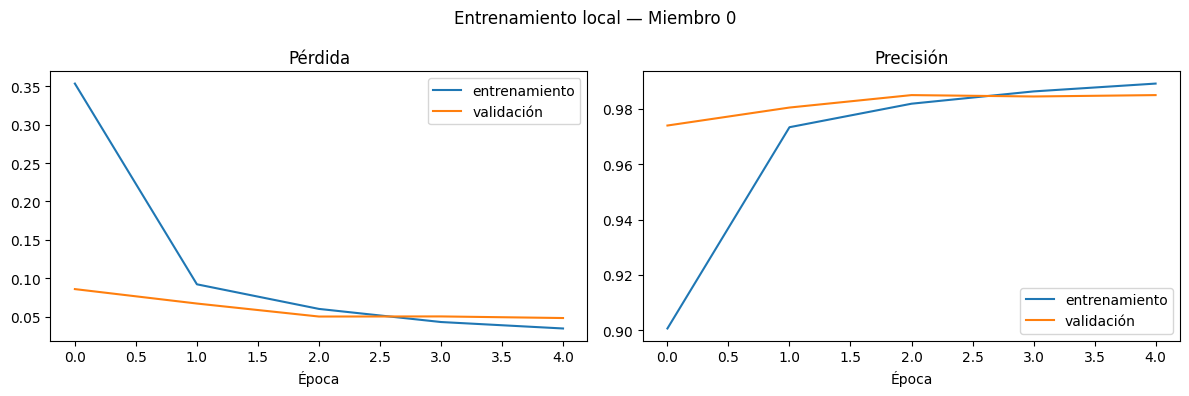

In [23]:
# ─── Curvas de aprendizaje ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],          label='entrenamiento')
ax1.plot(history.history['val_loss'],      label='validación')
ax1.set_title('Pérdida'); ax1.set_xlabel('Época'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='entrenamiento')
ax2.plot(history.history['val_accuracy'], label='validación')
ax2.set_title('Precisión'); ax2.set_xlabel('Época'); ax2.legend()

plt.suptitle(f'Entrenamiento local — Miembro {MEMBER_ID}')
plt.tight_layout()
plt.show()

In [24]:
# ─── Evaluación y guardado de pesos ──────────────────────────────────
y_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# Guarda los pesos en un archivo .npz para la agregación federada
# Se comparten todos estos archivos con el miembro que hará la agregación
weights_file = f'weights_{MEMBER_ID}.npz'
np.savez(weights_file, *model.get_weights())
print(f'\nPesos guardados en: {weights_file}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.93      1.00      0.96      1010
           4       1.00      0.98      0.99       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


Pesos guardados en: weights_0.npz
